In [ ]:
# Multi Layer Perceptron

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import StratifiedKFold

np.random.seed(42)
tf.random.set_seed(42)

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# To install the font library required for specific fonts
!wget -q -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
!wget -q -O /content/times.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/times.ttf
!wget -q -O /content/timesbd.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/timesbd.ttf

import matplotlib.font_manager as fm

fm.fontManager.addfont('/content/TimesNewRoman.ttf')
fm.fontManager.addfont('/content/times.ttf')
fm.fontManager.addfont('/content/timesbd.ttf')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [ ]:
# Printing the dataset information

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)
Number of classes: 10


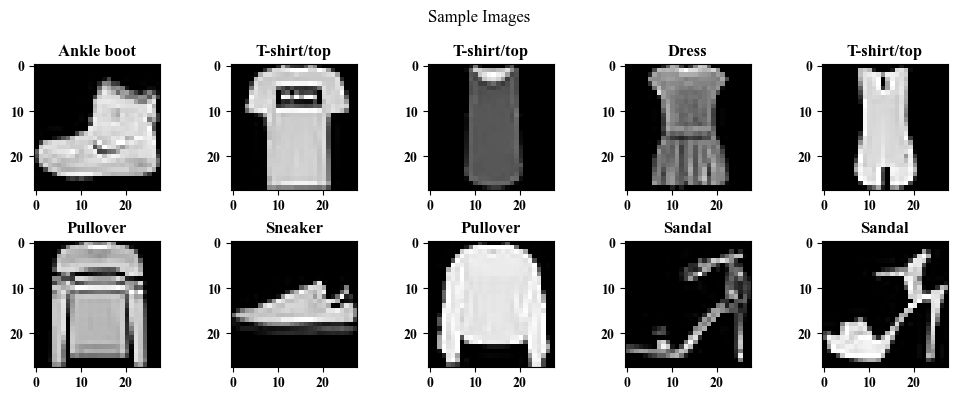

In [ ]:
# Displaying ten sample images

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
plt.suptitle("Sample Images")
plt.tight_layout()
plt.savefig(f"sampleImages.eps",dpi=600, format="eps")
plt.show()

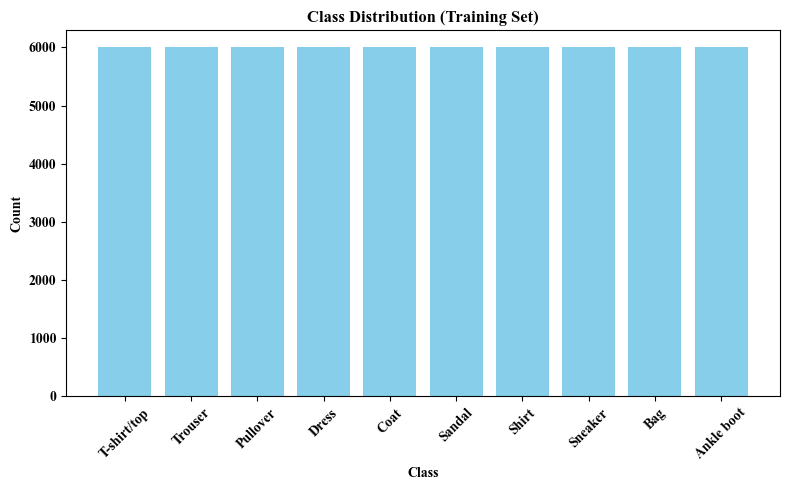

In [ ]:
# Plotting class distribution

unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar([class_names[i] for i in unique], counts, color='skyblue')
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Training Set)")
plt.tight_layout()
plt.savefig(f"classDistribution.eps",dpi=600, format="eps")
plt.show()

In [ ]:
print("Shape before preprocessing:", x_train.shape, x_test.shape)

# Normalizing

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

Shape before preprocessing: (60000, 28, 28) (10000, 28, 28)


In [ ]:
# One-hot encode labels

y_train_ohe = keras.utils.to_categorical(y_train, 10)
y_test_ohe = keras.utils.to_categorical(y_test, 10)

print("Shape after preprocessing:", x_train_flat.shape, x_test_flat.shape)
print("One-hot label shape:", y_train_ohe.shape, y_test_ohe.shape)

Shape after preprocessing: (60000, 784) (10000, 784)
One-hot label shape: (60000, 10) (10000, 10)


In [ ]:
# Baseline model

def build_baseline_model():
    baseline = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    baseline.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
    return baseline

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the model

baseline_start_time = time.time()

history = baseline_model.fit(
    x_train_flat, y_train_ohe,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

baseline_train_time = time.time() - baseline_start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8181 - loss: 0.5088 - val_accuracy: 0.8553 - val_loss: 0.4019
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8624 - loss: 0.3738 - val_accuracy: 0.8606 - val_loss: 0.3750
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8759 - loss: 0.3359 - val_accuracy: 0.8702 - val_loss: 0.3573
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8842 - loss: 0.3101 - val_accuracy: 0.8687 - val_loss: 0.3647
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8922 - loss: 0.2898 - val_accuracy: 0.8732 - val_loss: 0.3507
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8969 - loss: 0.2754 - val_accuracy: 0.8707 - val_loss: 0.3669
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9017 - loss: 0.2614 - val_accuracy: 0.8742 - val_loss: 0.3595
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9055 - loss: 0.2516 - 

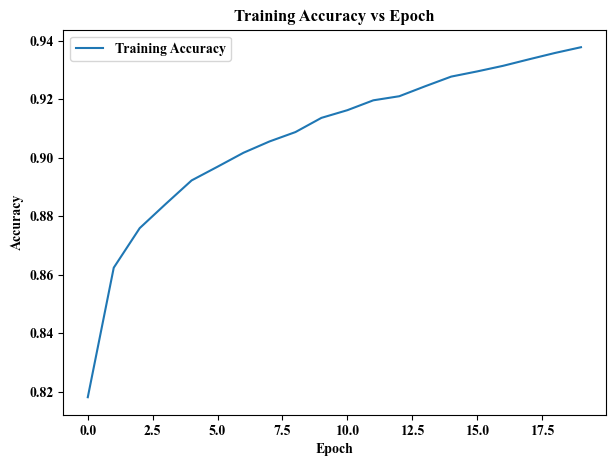

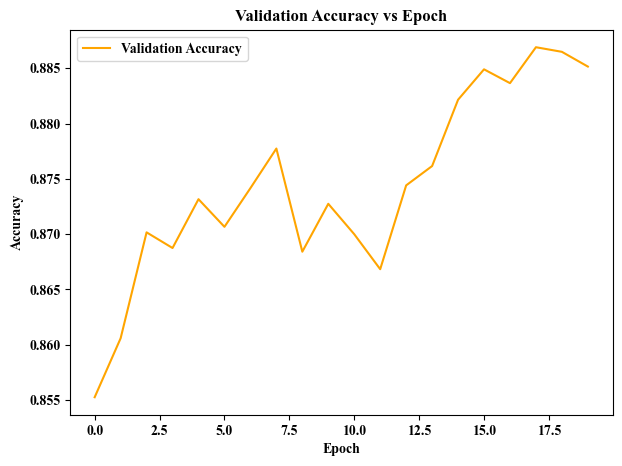

In [ ]:
# Training vs Validation Accuracy

plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.legend()
plt.savefig(f"trainingAccuracy.eps",dpi=600, format="eps")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()
plt.savefig(f"validationAccuracy.eps",dpi=600, format="eps")
plt.show()

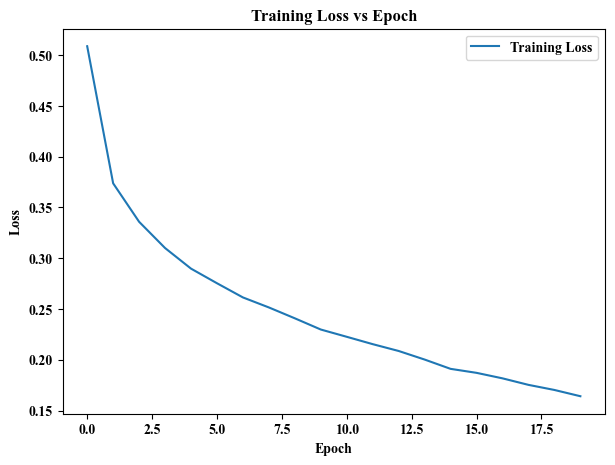

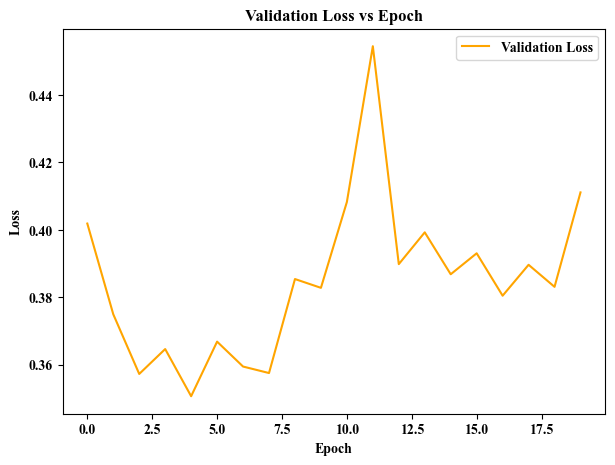

In [ ]:
# Training vs Validation Loss

plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.savefig(f"trainingLoss.eps",dpi=600, format="eps")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch")
plt.legend()
plt.savefig(f"validationLoss.eps",dpi=600, format="eps")
plt.show()

In [ ]:
# Statistics

y_pred_probs = baseline_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)

baseline_acc = accuracy_score(y_test, y_pred)
baseline_prec = precision_score(y_test, y_pred, average='weighted')
baseline_rec = recall_score(y_test, y_pred, average='weighted')
baseline_f1 = f1_score(y_test, y_pred, average='weighted')

print("Baseline Accuracy :", baseline_acc)
print("Baseline Precision:", baseline_prec)
print("Baseline Recall   :", baseline_rec)
print("Baseline F1-score :", baseline_f1)

print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Baseline Accuracy : 0.8765
Baseline Precision: 0.8792961228013979
Baseline Recall   : 0.8765
Baseline F1-score : 0.8771496807309098

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.87      0.78      0.83      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.77      0.80      0.78      1000
       Dress       0.89      0.87      0.88      1000
        Coat       0.75      0.85      0.79      1000
      Sandal       0.97      0.94      0.96      1000
       Shirt       0.69      0.70      0.70      1000
     Sneaker       0.92      0.97      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.96      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



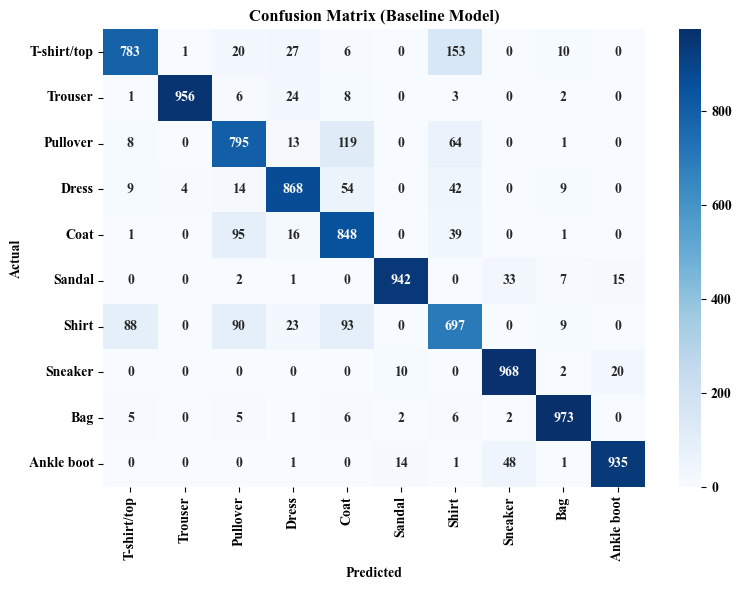

In [ ]:
# Confusion matrix for the baseline model

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Baseline Model)")
plt.tight_layout()
plt.savefig(f"confusionMatrix.eps",dpi=600, format="eps")
plt.show()

In [ ]:
# Model for hyperparameter tuning

def build_model_for_search(hidden_layers=1, hidden_neurons=128, learning_rate=0.001,
                            optimizer='adam', activation='relu', dropout_rate=0.0):
    search_model = keras.Sequential()
    search_model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        search_model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            search_model.add(layers.Dropout(dropout_rate))
    search_model.add(layers.Dense(10, activation='softmax'))

    if optimizer == 'adam':
        opt =keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    search_model.compile(optimizer= opt, loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return search_model

In [ ]:
# Hyperparameter search space (as specified in the lab manual)
param_space = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'optimizer': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}


def sample_params(space):
    return {k: random.choice(v) for k, v in space.items()}

In [ ]:
# Using a subset of the training data for the search (Reduces performance but faster search)

x_search = x_train_flat[:10000]
y_search = y_train_ohe[:10000]
y_search_labels = np.argmax(y_search, axis=1)

N_ITER = 20
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

search_results = []
search_start_time = time.time()

for i in range(N_ITER):
    params = sample_params(param_space)
    fold_scores = []

    for train_idx, val_idx in skf.split(x_search, y_search_labels):
        x_tr, x_val = x_search[train_idx], x_search[val_idx]
        y_tr, y_val = y_search[train_idx], y_search[val_idx]

        candidate_model = build_model_for_search(
            hidden_layers=params['hidden_layers'],
            hidden_neurons=params['hidden_neurons'],
            learning_rate=params['learning_rate'],
            optimizer=params['optimizer'],
            activation=params['activation'],
            dropout_rate=params['dropout_rate']
        )

        candidate_model.fit(
            x_tr, y_tr,
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            verbose=0
        )

        _, val_acc = candidate_model.evaluate(x_val, y_val, verbose=0)
        fold_scores.append(val_acc)
        keras.backend.clear_session()

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    search_results.append({**params, 'mean_test_score': mean_score, 'std_test_score': std_score})

    print(f"[{i + 1}/{N_ITER}] mean_cv_acc={mean_score:.4f}  params={params}")

search_time = time.time() - search_start_time
print(f"\nHyperparameter search time: {search_time:.2f} seconds")

[1/20] mean_cv_acc=0.1166  params={'hidden_layers': 3, 'hidden_neurons': 32, 'learning_rate': 0.1, 'optimizer': 'rmsprop', 'activation': 'tanh', 'dropout_rate': 0.0, 'batch_size': 32, 'epochs': 10}
[2/20] mean_cv_acc=0.0980  params={'hidden_layers': 3, 'hidden_neurons': 256, 'learning_rate': 0.1, 'optimizer': 'adam', 'activation': 'sigmoid', 'dropout_rate': 0.2, 'batch_size': 16, 'epochs': 10}
[3/20] mean_cv_acc=0.2229  params={'hidden_layers': 1, 'hidden_neurons': 32, 'learning_rate': 0.1, 'optimizer': 'rmsprop', 'activation': 'relu', 'dropout_rate': 0.2, 'batch_size': 16, 'epochs': 10}
[4/20] mean_cv_acc=0.6749  params={'hidden_layers': 3, 'hidden_neurons': 32, 'learning_rate': 0.001, 'optimizer': 'rmsprop', 'activation': 'relu', 'dropout_rate': 0.5, 'batch_size': 32, 'epochs': 10}
[5/20] mean_cv_acc=0.7946  params={'hidden_layers': 2, 'hidden_neurons': 64, 'learning_rate': 0.01, 'optimizer': 'sgd', 'activation': 'relu', 'dropout_rate': 0.5, 'batch_size': 64, 'epochs': 30}
[6/20] mea

In [ ]:
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values('mean_test_score', ascending=False).reset_index(drop=True)

best_row = results_df_sorted.iloc[0]
best_params = {
    'hidden_layers': int(best_row['hidden_layers']),
    'hidden_neurons': int(best_row['hidden_neurons']),
    'learning_rate': float(best_row['learning_rate']),
    'optimizer': best_row['optimizer'],
    'activation': best_row['activation'],
    'dropout_rate': float(best_row['dropout_rate']),
    'batch_size': int(best_row['batch_size']),
    'epochs': int(best_row['epochs'])
}
best_cv_score = best_row['mean_test_score']

print("Best CV Score:", best_cv_score)
print("Best Params:", best_params)

Best CV Score: 0.8497000098228454
Best Params: {'hidden_layers': 3, 'hidden_neurons': 128, 'learning_rate': 0.01, 'optimizer': 'adam', 'activation': 'relu', 'dropout_rate': 0.0, 'batch_size': 128, 'epochs': 30}


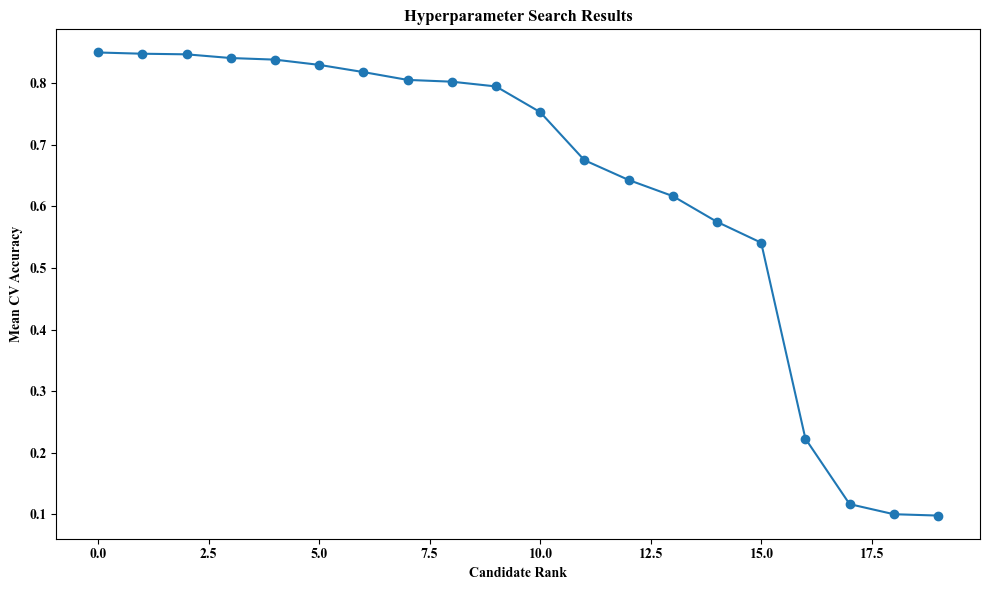

In [ ]:
# Hyperparameter Search Results plot

plt.figure(figsize=(10, 6))
plt.plot(range(len(results_df_sorted)), results_df_sorted['mean_test_score'].values, marker='o')
plt.xlabel("Candidate Rank")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results")
plt.tight_layout()
plt.savefig(f"hyperparameterSearch.eps",dpi=600, format="eps")
plt.show()

In [ ]:
# Training the optimized model on the full dataset

optimized_model = build_model_for_search(
    hidden_layers=best_params['hidden_layers'],
    hidden_neurons=best_params['hidden_neurons'],
    learning_rate=best_params['learning_rate'],
    optimizer=best_params['optimizer'],
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate']
)

optimized_model.summary()

opt_start_time = time.time()
opt_history = optimized_model.fit(
    x_train_flat, y_train_ohe,
    validation_split=0.2,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)
optimized_train_time = time.time() - opt_start_time
print(f"Optimized model training time: {optimized_train_time:.2f} seconds")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7920 - loss: 0.5680 - val_accuracy: 0.8374 - val_loss: 0.4362
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8479 - loss: 0.4147 - val_accuracy: 0.8464 - val_loss: 0.4182
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8624 - loss: 0.3844 - val_accuracy: 0.8559 - val_loss: 0.4082
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8641 - loss: 0.3719 - val_accuracy: 0.8527 - val_loss: 0.4197
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8694 - loss: 0.3619 - val_accuracy: 0.8483 - val_loss: 0.4369
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8739 - loss: 0.3481 - val_accuracy: 0.8575 - val_loss: 0.4258
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8755 - loss: 0.3427 - val_accuracy: 0.8541 - val_loss: 0.4177
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8769 - loss: 0.3403 - val_accuracy: 0.

In [ ]:
# Statistics of the optimized model

y_pred_opt_probs = optimized_model.predict(x_test_flat)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='weighted')
opt_rec = recall_score(y_test, y_pred_opt, average='weighted')
opt_f1 = f1_score(y_test, y_pred_opt, average='weighted')

print("Optimized Accuracy :", opt_acc)
print("Optimized Precision:", opt_prec)
print("Optimized Recall   :", opt_rec)
print("Optimized F1-score :", opt_f1)

print("\nClassification Report (Optimized):\n",
      classification_report(y_test, y_pred_opt, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Optimized Accuracy : 0.8473
Optimized Precision: 0.8637496706579275
Optimized Recall   : 0.8473
Optimized F1-score : 0.849856602819645

Classification Report (Optimized):
               precision    recall  f1-score   support

 T-shirt/top       0.86      0.60      0.71      1000
     Trouser       0.99      0.95      0.97      1000
    Pullover       0.83      0.71      0.77      1000
       Dress       0.83      0.88      0.86      1000
        Coat       0.78      0.73      0.75      1000
      Sandal       0.96      0.95      0.96      1000
       Shirt       0.53      0.79      0.63      1000
     Sneaker       0.93      0.94      0.94      1000
         Bag       0.96      0.97      0.96      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



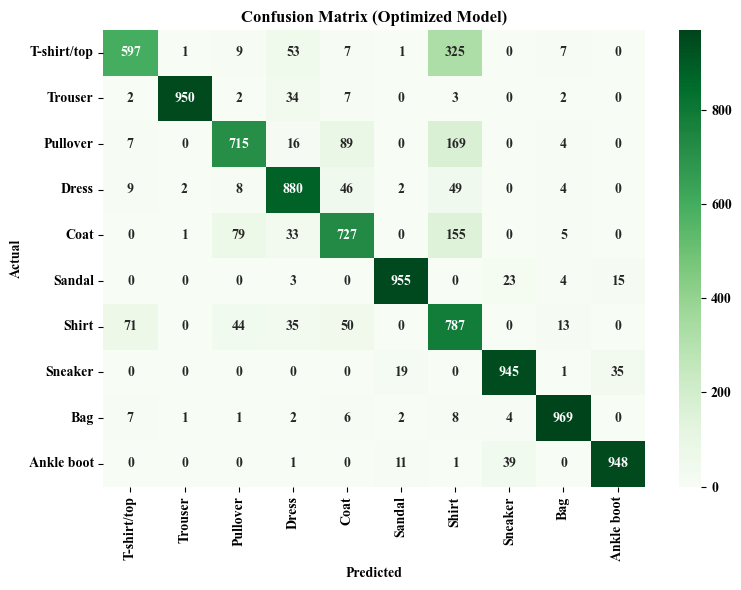

In [ ]:
# Confusion matrix for the optimized model

cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Optimized Model)")
plt.tight_layout()
plt.savefig(f"confusionMatrixOptimized.eps",dpi=600, format="eps")
plt.show()

In [ ]:
# Comparing baseline and optimized

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Training Time (s)'],
    'Baseline': [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_train_time],
    'Optimized': [opt_acc, opt_prec, opt_rec, opt_f1, optimized_train_time]
})
print(metrics_comparison)

              Metric    Baseline  Optimized
0           Accuracy    0.876500   0.847300
1          Precision    0.879296   0.863750
2             Recall    0.876500   0.847300
3           F1-score    0.877150   0.849857
4  Training Time (s)  113.420512  46.206597


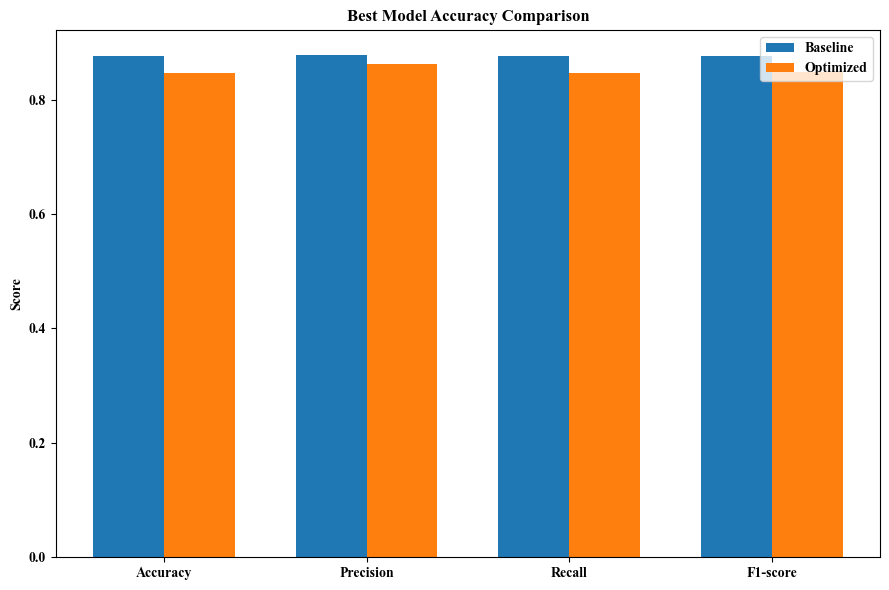

In [ ]:
# Graph for comparison

labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_vals = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
optimized_vals = [opt_acc, opt_prec, opt_rec, opt_f1]

x_pos = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x_pos - width / 2, baseline_vals, width, label='Baseline')
plt.bar(x_pos + width / 2, optimized_vals, width, label='Optimized')
plt.xticks(x_pos, labels)
plt.ylabel("Score")
plt.title("Best Model Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(f"bestModelComparison.eps",dpi=600, format="eps")
plt.show()

In [ ]:
print("Best Hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nCross-validation Accuracy: {best_cv_score:.4f}")
print(f"Testing Accuracy: {opt_acc:.4f}")

Best Hyperparameters:
  hidden_layers: 3
  hidden_neurons: 128
  learning_rate: 0.01
  optimizer: adam
  activation: relu
  dropout_rate: 0.0
  batch_size: 128
  epochs: 30

Cross-validation Accuracy: 0.8497
Testing Accuracy: 0.8473
